In [106]:
import pandas as pd
import pickle
from pathlib import Path

df  = pd.read_parquet("data.parquet")

# affiche les nombres sans notation scientifique avec pandas
pd.set_option("display.float_format", "{:,.2f}".format)

X_test  = pd.read_parquet("X_test.parquet")
y_test  = pd.read_parquet("y_test.parquet")

X_train  = pd.read_parquet("X_train.parquet")
y_train  = pd.read_parquet("y_train.parquet")

print("Longueur du test initial :", len(X_test))
print("Longueur du train initial :", len(X_train))

# dans l'approche LLM, il n'est pas possible de prédire un Tag sans le texte de réclamation
# `X_test` et `y_test` ont conserver les index de `df`
filter = (X_test["Consumer Claim"].notna() & X_test["Consumer Claim"].str.strip().ne(""))
X_test  = X_test.loc[filter]
y_test  = y_test.loc[filter]

filter = (X_train["Consumer Claim"].notna() & X_train["Consumer Claim"].str.strip().ne(""))
X_train  = X_train.loc[filter]
y_train  = y_train.loc[filter]

print("Longueur du test filtré  :", len(X_test))
print("Longueur du train filtré  :", len(X_train))

# Chargement des catégories
with open("categories.pkl", "rb") as f:
    categories = pickle.load(f)

# stockage des metriques
global_metrics = []

# crée les dossiers
Path("tests").parent.mkdir(parents=True, exist_ok=True)
Path("database").parent.mkdir(parents=True, exist_ok=True)
Path("models").parent.mkdir(parents=True, exist_ok=True)


Longueur du test initial : 256471
Longueur du train initial : 1025884
Longueur du test filtré  : 76791
Longueur du train filtré  : 306773


# Approche LLM

On demande au LLM de choisir parmis la catégorie 'Tag' en fonction de la demande client 'Consumer Claim'

In [107]:
import os
import pandas as pd

from mistralai.client import Mistral


# Client Mistral
client = Mistral(
    api_key=os.environ["MISTRAL_API_KEY"]
)


# ---------------------------------------------------------
# Préparation du prompt système
# ---------------------------------------------------------

SYSTEM_PROMPT = """
Vous êtes un système de classification de réclamations clientes.

Votre tâche consiste à attribuer à chaque réclamation UNE SEULE catégorie parmi les catégories autorisées.

Vous devez retourner exactement le nom d'une catégorie présente dans la liste fournie, sans explication supplémentaire.

Catégories autorisées :
{categories}

{additional_prompt}
"""


# ---------------------------------------------------------
# Fonction de classification
# ---------------------------------------------------------

def classify_with_llm(
    claim: str,
    categories: list[str],
    model: str = os.environ["MISTRAL_MODEL"],
    temperature: float = 0.0,
    additional_prompt: str = None
) -> str:
    """
    Classifie une réclamation client à l'aide d'un modèle de langage Mistral.

    La fonction construit un prompt système contenant la liste des catégories
    autorisées, puis soumet la réclamation au modèle afin qu'il détermine la
    catégorie correspondante.

    Args:
        claim (str):
            Texte de la réclamation client à classifier.

        categories (list[str]):
            Liste des catégories autorisées pour la classification.
            Le modèle doit retourner exactement l'une de ces catégories.

        model (str, optional):
            Identifiant du modèle Mistral utilisé pour la classification.
            Par défaut, "mistral-small-latest".

        temperature (float, optional):
            Paramètre contrôlant le niveau de variabilité de la réponse.
            Une valeur de 0.0 est utilisée par défaut afin de rendre la
            classification aussi déterministe que possible.

    Returns:
        str:
            Catégorie prédite par le modèle. Les espaces superflus au début
            et à la fin de la réponse sont supprimés.

    Raises:
        Exception:
            Une exception peut être levée si l'appel à l'API Mistral échoue
            ou si la réponse retournée ne possède pas le format attendu.

    Example:
        categories = [
            "Checking or savings account",
            "Debt collection",
            "Mortgage",
        ]

        category = classify_with_llm(
            claim="I have a problem with my mortgage payment.",
            categories=categories,
        )

        print(category)
    """

    #print(model)

    system_prompt = SYSTEM_PROMPT.format(
        categories="\n".join(f"- {category}" for category in categories),
        additional_prompt=additional_prompt
    )

    #print(system_prompt)

    user_prompt = f"""
Réclamation à classifier :

{claim}

Retournez uniquement la catégorie correspondante.
"""

    #print(user_prompt)

    response = client.chat.complete(
        model=model,
        temperature=temperature,
        messages=[
            {
                "role": "system",
                "content": system_prompt,
            },
            {
                "role": "user",
                "content": user_prompt,
            },
        ],
    )

    return response.choices[0].message.content.strip(), response.usage

In [108]:
import random
import time

def with_retry(func: callable, max_retries=5):
    """
    Exécute une fonction avec une stratégie de nouvelle tentative automatique.

    La fonction est exécutée et, en cas d'exception, elle est relancée
    automatiquement jusqu'à atteindre le nombre maximal de tentatives.
    Le délai entre les tentatives augmente de manière exponentielle et
    une durée aléatoire est ajoutée afin d'éviter que plusieurs appels
    simultanés ne soient effectués exactement au même moment.

    Lorsque le nombre maximal de tentatives est atteint, l'utilisateur
    peut choisir de poursuivre le traitement en réinitialisant le compteur
    de tentatives ou d'arrêter le traitement.

    Args:
        func (callable):
            Fonction sans argument à exécuter.

        max_retries (int, optional):
            Nombre maximal de tentatives consécutives avant de demander
            à l'utilisateur s'il souhaite poursuivre. Par défaut à 5.

    Returns:
        Any:
            Résultat retourné par `func` lorsque son exécution réussit.

        None:
            Si le nombre maximal de tentatives est atteint et que
            l'utilisateur choisit d'arrêter le traitement.

    Raises:
        Exception:
            Les exceptions levées par `func` sont interceptées. Elles ne
            sont donc pas propagées lorsque l'utilisateur choisit de
            poursuivre ou d'arrêter le traitement.

    Notes:
        Le délai avant chaque nouvelle tentative suit la formule :

            2 ** attempt + random.uniform(0, 1)

        Il augmente donc progressivement afin de limiter les appels
        répétés et rapprochés vers le service distant.

    Example:
        result = with_retry(
            lambda: client.chat.complete(
                model="mistral-small-latest",
                messages=messages
            )
        )
    """
    attempt = 0

    while True:
        try:
            return func()

        except Exception as e:
            attempt += 1

            if attempt >= max_retries:
                print(f"Échec de l'appel : {e}")

                answer = input(
                    "Le nombre de tentatives est écoulé. "
                    "Continuer tout de même ? (o/n) : "
                ).strip().lower()

                if answer not in ["o", "oui", "y", "yes"]:
                    print("Traitement arrêté.")
                    return None

                # Nouvelle série de tentatives
                attempt = 0
                continue

            wait_time = (
                2 ** attempt
                + random.uniform(0, 1)
            )

            print(f"Erreur de l'appel : {e}")
            print(
                f"Nouvelle tentative dans "
                f"{wait_time:.2f} secondes..."
            )

            time.sleep(wait_time)

# Fonction affiche le coût estimé des tokens / €

In [109]:
def print_tokens_cost(model, results):
    input_price = float(os.environ["MISTRAL_MODEL_INPUT_COST_1M_TOKEN"] if model == os.environ["MISTRAL_MODEL"] else os.environ["MISTRAL_MEDIUM_MODEL_INPUT_COST_1M_TOKEN"] if model == os.environ["MISTRAL_MEDIUM_MODEL"] else os.environ["MISTRAL_LARGE_MODEL_INPUT_COST_1M_TOKEN"])
    outut_price = float(os.environ["MISTRAL_MODEL_OUTPUT_COST_1M_TOKEN"] if model == os.environ["MISTRAL_MODEL"] else os.environ["MISTRAL_MEDIUM_MODEL_OUTPUT_COST_1M_TOKEN"] if model == os.environ["MISTRAL_MEDIUM_MODEL"] else os.environ["MISTRAL_LARGE_MODEL_OUTPUT_COST_1M_TOKEN"])

    input_tokens = results["Input Tokens"].sum()
    output_tokens = results["Output Tokens"].sum()

    input_cost = (input_tokens * input_price)  / 1_000_000.0
    output_cost = (output_tokens * outut_price)  / 1_000_000.0
    total_cost = input_cost + output_cost
    
    print(
        "Tokens:\n",
        "Coût entrée ($)", f"{input_cost:.6f}", "(", input_tokens, "tokens )", "\n",
        "Coût sortie ($)", f"{output_cost:.6f}", "(", output_tokens, "tokens )", "\n",
        "Coût total  ($)", f"{total_cost:.6f}", "(", input_tokens + output_tokens, "tokens )", "\n",
    )

# Fonctions de stockage des résultats

In [110]:
import pickle
from pathlib import Path

def load_results(results_path):
    print("load_results", results_path)
    if results_path.exists():
        # sauvegarde également les différentes catègories
        with open(results_path, "rb") as f:
            return pickle.load(f)
    else:
        return pd.DataFrame()
        
def save_results(results, results_path):
    # sauvegarde également les différentes catègories
    with open(results_path, "wb") as f:
        pickle.dump(results, f)

# Fonction de sélection d'échantillons

In [111]:
import math
# Sélectionne un nombre equitable d'éléments dans chaque catégorie (évite d'ignorer catégories peut représenté)
def sampling(max_results, y_test):
    n_per_category = math.ceil(max_results / len(categories))
    return (
        y_test.groupby("Tag", group_keys=False)
        .apply(lambda x: x.sample(
            n=min(len(x), n_per_category),
            random_state=42
        ))
    ).index

# Fonction de test

In [112]:
from collections.abc import Callable
import time
import pandas as pd


def test(
    indices,
    additional_prompt: str | Callable[[str], str] | None = None,
    batch=None,
    **kwargs
) -> pd.DataFrame:
    """
    Évalue les performances du modèle de classification sur un ensemble
    d'indices du jeu de test.

    Pour chaque réclamation, la fonction construit éventuellement un prompt
    complémentaire, puis effectue la classification via `with_retry`.
    Le prompt complémentaire peut être fourni directement sous forme de
    chaîne de caractères ou être généré dynamiquement par une fonction.

    Args:
        indices:
            Collection d'indices correspondant aux lignes de `X_test` et
            `y_test` à utiliser pour l'évaluation.

        additional_prompt (str | Callable[[str], str] | None, optional):
            Prompt complémentaire à ajouter au prompt de classification.

            Trois comportements sont possibles :

            - `None` : aucun prompt complémentaire.
            - `str` : le même prompt est utilisé pour toutes les questions.
            - `Callable[[str], str]` : la fonction est appelée pour chaque
              question avec le texte de la réclamation comme argument.
              Elle doit retourner le prompt complémentaire à utiliser.

    Returns:
        pd.DataFrame:
            Tableau récapitulatif contenant les résultats de chaque test.

            Colonnes :
            - `Index` : index de la réclamation.
            - `Question` : réclamation testée.
            - `Réponse` : catégorie prédite.
            - `Attendue` : catégorie réelle.
            - `Correct` : indique si la prédiction est correcte.
            - `Temps (s)` : temps nécessaire pour obtenir la réponse.

    Raises:
        TypeError:
            Si `additional_prompt` n'est ni `None`, ni une chaîne de
            caractères, ni une fonction appelable.

    Example:
        # Prompt fixe
        results = test(
            indices,
            additional_prompt="Soyez particulièrement attentif..."
        )

        # Prompt généré dynamiquement
        def get_examples(question):
            examples = retrieve_examples(
                metadata,
                question,
                k=3
            )

            return format_examples(examples)

        results = test(
            indices,
            additional_prompt=get_examples
        )
    """

    results = []

    for idx in indices:
        X = X_test.loc[idx]
        y = y_test.loc[idx]

        question = X["Consumer Claim"]
        expected = y["Tag"]
        
        # Génération du prompt complémentaire
        if additional_prompt is None:
            prompt = None
        elif isinstance(additional_prompt, str):
            prompt = additional_prompt
        elif callable(additional_prompt):
            prompt = additional_prompt(question)
        else:
            raise TypeError(
                "additional_prompt doit être None, "
                "une chaîne de caractères ou une fonction callable."
            )

        start = time.perf_counter()

        response, usage = with_retry(
            lambda: classify_with_llm(
                question,
                categories,
                additional_prompt=prompt,
                **kwargs
            )
        )

        elapsed = time.perf_counter() - start

        if response not in categories:
            break

        results.append({
            "Index": idx,
            "Question": question,
            "Réponse": response,
            "Attendue": expected,
            "Correct": response == expected,
            "Temps (s)": elapsed,
            "Total Tokens": usage.total_tokens,
            "Input Tokens": usage.prompt_tokens,
            "Output Tokens": usage.completion_tokens
        })

        if batch and len(results) >= batch:
            print("Batch terminé avec", len(results), "tests réalisés")
            break

    return pd.DataFrame(results)

# Test avec 1 ligne de données du dataset

In [113]:
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

name = "test 1"
model = os.environ["MISTRAL_MODEL"]
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)

if len(results) == 0:
    print("Démarre le test:", name, "avec", model)
    indices = X_test.index[:1]
    results = test(indices, model=model)
    save_results(results, results_path)

metrics = calculate_metrics(name, model, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)
print("------------------------")
print_tokens_cost(model, results)

global_metrics.append(metrics)

load_results tests\test 1.pkl

------------------------
test 1
------------------------
Name : test 1
Method : mistral-small-latest
Samples : 1
Accuracy : 100.00%
Precision (macro) : 100.00%
Recall (macro) : 100.00%
F1 (macro) : 100.00%
Precision (weighted) : 100.00%
Recall (weighted) : 100.00%
F1 (weighted) : 100.00%
Temps moyen (s) : 0.6279 s
Temps médian (s) : 0.6279 s
Temps P95 (s) : 0.6279 s

------------------------
                                                                              precision    recall  f1-score   support

Credit reporting, credit repair services, or other personal consumer reports       1.00      1.00      1.00         1

                                                                    accuracy                           1.00         1
                                                                   macro avg       1.00      1.00      1.00         1
                                                                weighted avg       1.00      1.00   

# Test avec 20 lignes de données du dataset

In [114]:
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

name = "test 20"
model = os.environ["MISTRAL_MODEL"]
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)

if len(results) == 0:
    print("Démarre le test:", name, "avec", model)
    indices = sampling(20, y_test)
    print(y_test.loc[indices]["Tag"].value_counts())
    results = test(indices, model=model)
    save_results(results, results_path)

metrics = calculate_metrics(name, model, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)
print("------------------------")
print_tokens_cost(model, results)

global_metrics.append(metrics)

load_results tests\test 20.pkl

------------------------
test 20
------------------------
Name : test 20
Method : mistral-small-latest
Samples : 20
Accuracy : 70.00%
Precision (macro) : 74.00%
Recall (macro) : 70.00%
F1 (macro) : 67.71%
Precision (weighted) : 74.00%
Recall (weighted) : 70.00%
F1 (weighted) : 67.71%
Temps moyen (s) : 0.5825 s
Temps médian (s) : 0.5465 s
Temps P95 (s) : 0.9033 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       1.00      0.50      0.67         2
                                                 Credit card or prepaid card       0.67      1.00      0.80         2
Credit reporting, credit repair services, or other personal consumer reports       0.40      1.00      0.57         2
                                                             Debt collection       0.33      0.50      0

## Test avec des exemples pour chaque catégorie

In [115]:
examples = (
    df.dropna(subset=["Consumer Claim"])
      .groupby("Tag", group_keys=False)
      .sample(n=3, random_state=42)
      .sort_values("Tag")
)

examples_text = "\n\n".join(
    f"Catégorie : {row['Tag']}\n"
    f"Réclamation : {row['Consumer Claim']}"
    for _, row in examples.iterrows()
)

In [116]:

# ---------------------------------------------------------
# Préparation du prompt système
# ---------------------------------------------------------

additional_prompt = """
Voici des exemples de réclamation correctement classées:
{examples_text}
"""


In [117]:
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

name = "test 20 avec exemples"
model = os.environ["MISTRAL_MODEL"]
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)

if len(results) == 0:
    print("Démarre le test:", name, "avec", model)
    indices = sampling(20, y_test)
    print(y_test.loc[indices]["Tag"].value_counts())
    results = test(indices, additional_prompt, model=model)
    save_results(results, results_path)

metrics = calculate_metrics(name, model, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)
print("------------------------")
print_tokens_cost(model, results)

global_metrics.append(metrics)

load_results tests\test 20 avec exemples.pkl

------------------------
test 20 avec exemples
------------------------
Name : test 20 avec exemples
Method : mistral-small-latest
Samples : 20
Accuracy : 65.00%
Precision (macro) : 70.00%
Recall (macro) : 65.00%
F1 (macro) : 63.00%
Precision (weighted) : 70.00%
Recall (weighted) : 65.00%
F1 (weighted) : 63.00%
Temps moyen (s) : 1.0657 s
Temps médian (s) : 0.5153 s
Temps P95 (s) : 4.0749 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       1.00      0.50      0.67         2
                                                 Credit card or prepaid card       0.67      1.00      0.80         2
Credit reporting, credit repair services, or other personal consumer reports       0.33      1.00      0.50         2
                                                             D

## Test avec des exemples du RAG

* Initialise une base de données vectoriel avec le jeu d'entrainement
* Récupère n exemples du système RAG pour insérer au prompt
* Test le LLM

In [118]:
from rag import (
    load_database,
    save_database,
    make_database,
    retrieve_examples,
)

try:
    metadata, index = load_database()
except Exception as e:
    print(e)
    # ----------------------------------------------------------------
    # Construire l'index FAISS uniquement avec le jeu d'entraînement
    # ----------------------------------------------------------------

    train_data = X_train.copy()

    train_data["Tag"] = y_train["Tag"]

    # Suppression des doublons
    train_data = train_data.drop_duplicates(
        subset=["Consumer Claim"]
    ).reset_index(drop=True)

    print(f"Création de la base de données sur un jeu de {len(train_data)} lignes")

    # ----------------------------------------------------------------
    # Création de la base de données
    # ----------------------------------------------------------------

    metadata, index = make_database(train_data)


    # ----------------------------------------------------------------
    # Sauvegarde de la base de données
    # ----------------------------------------------------------------

    save_database(metadata, index)

In [119]:
# ----------------------------------------------------------------
# Crée des exemples
# ----------------------------------------------------------------

def create_samples(question):
    examples = retrieve_examples(
        metadata,
        index,
        question,
        k=10
    )

    examples_text = "\n\n".join(
        f"Catégorie : {row['Tag']}\n"
        f"Réclamation : {row['Consumer Claim']}"
        for _, row in examples.iterrows()
    )

    return f"""
    Voici des exemples de réclamation correctement classées:
    {examples_text}
    """

In [120]:
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

# ----------------------------------------------------------------
# Test
# ----------------------------------------------------------------

name = "test 20 avec exemples ciblés"
model = os.environ["MISTRAL_MODEL"]
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)

if len(results) == 0:
    print("Démarre le test:", name, "avec", model)
    
    indices = sampling(20, y_test)
    print(y_test.loc[indices]["Tag"].value_counts())
    results = test(indices, create_samples, model=model)
    save_results(results, results_path)

metrics = calculate_metrics(name, model, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)
print("------------------------")
print_tokens_cost(model, results)

global_metrics.append(metrics)

load_results tests\test 20 avec exemples ciblés.pkl

------------------------
test 20 avec exemples ciblés
------------------------
Name : test 20 avec exemples ciblés
Method : mistral-small-latest
Samples : 20
Accuracy : 70.00%
Precision (macro) : 76.67%
Recall (macro) : 70.00%
F1 (macro) : 69.00%
Precision (weighted) : 76.67%
Recall (weighted) : 70.00%
F1 (weighted) : 69.00%
Temps moyen (s) : 1.2524 s
Temps médian (s) : 0.5190 s
Temps P95 (s) : 1.4248 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       1.00      0.50      0.67         2
                                                 Credit card or prepaid card       1.00      1.00      1.00         2
Credit reporting, credit repair services, or other personal consumer reports       0.33      1.00      0.50         2
                                         

## Test avec un modèle medium

In [121]:
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

# ----------------------------------------------------------------
# Test
# ----------------------------------------------------------------

name = "test 20 avec exemples ciblés et modèle medium"
model = os.environ["MISTRAL_MEDIUM_MODEL"]
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)

if len(results) == 0:
    print("Démarre le test:", name, "avec", model)
    
    indices = sampling(20, y_test)
    print(y_test.loc[indices]["Tag"].value_counts())
    results = test(indices, create_samples, model=model)
    save_results(results, results_path)

metrics = calculate_metrics(name, model, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)
print("------------------------")
print_tokens_cost(model, results)

global_metrics.append(metrics)

load_results tests\test 20 avec exemples ciblés et modèle medium.pkl

------------------------
test 20 avec exemples ciblés et modèle medium
------------------------
Name : test 20 avec exemples ciblés et modèle medium
Method : mistral-medium-latest
Samples : 20
Accuracy : 75.00%
Precision (macro) : 79.00%
Recall (macro) : 75.00%
F1 (macro) : 72.38%
Precision (weighted) : 79.00%
Recall (weighted) : 75.00%
F1 (weighted) : 72.38%
Temps moyen (s) : 5.5377 s
Temps médian (s) : 3.2222 s
Temps P95 (s) : 19.2289 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       1.00      0.50      0.67         2
                                                 Credit card or prepaid card       1.00      1.00      1.00         2
Credit reporting, credit repair services, or other personal consumer reports       0.40      1.00      0.5

## Test avec un modèle large

In [122]:
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

# ----------------------------------------------------------------
# Test
# ----------------------------------------------------------------

name = "test 20 avec exemples ciblés et modèle large"
model = os.environ["MISTRAL_LARGE_MODEL"]
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)

if len(results) == 0:
    print("Démarre le test:", name, "avec", model)
    
    indices = sampling(20, y_test)
    print(y_test.loc[indices]["Tag"].value_counts())
    results = test(indices, create_samples, model=model)
    save_results(results, results_path)

metrics = calculate_metrics(name, model, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)
print("------------------------")
print_tokens_cost(model, results)

global_metrics.append(metrics)

load_results tests\test 20 avec exemples ciblés et modèle large.pkl

------------------------
test 20 avec exemples ciblés et modèle large
------------------------
Name : test 20 avec exemples ciblés et modèle large
Method : mistral-large-latest
Samples : 20
Accuracy : 75.00%
Precision (macro) : 79.00%
Recall (macro) : 75.00%
F1 (macro) : 72.38%
Precision (weighted) : 79.00%
Recall (weighted) : 75.00%
F1 (weighted) : 72.38%
Temps moyen (s) : 191.0669 s
Temps médian (s) : 120.6162 s
Temps P95 (s) : 428.3055 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       1.00      0.50      0.67         2
                                                 Credit card or prepaid card       1.00      1.00      1.00         2
Credit reporting, credit repair services, or other personal consumer reports       0.50      1.00      0.

# Evaluation

Evalue le système sur un échantillonnage plus important et affiche les metriques
(le test peut être exécuté en plusieurs fois)

In [123]:
max_results = 1000
samples = sampling(max_results, y_test)
print(y_test.loc[samples]["Tag"].value_counts())

Tag
Checking or savings account                                                     100
Credit card or prepaid card                                                     100
Credit reporting, credit repair services, or other personal consumer reports    100
Debt collection                                                                 100
Money transfer, virtual currency, or money service                              100
Mortgage                                                                        100
Payday loan, title loan, or personal loan                                       100
Student loan                                                                    100
Vehicle loan or lease                                                           100
Other financial service                                                         55 
Name: count, dtype: int64


In [124]:
from metrics import (
    calculate_metrics,
    print_metrics,
    print_report,
)

name = "test 1000"
model = os.environ["MISTRAL_MODEL"]
results_path = Path("tests", name + ".pkl")
results = load_results(results_path)

while len(results) < len(samples):
    print("Démarre le test:", name, "avec", model)
    print(len(results), "/", max_results)

    # reprend la où ont s'était arrêté (random_state permet de reproduire l'ordre exacte dans indices)
    indices = samples[len(results):max_results]

    additional_results = test(indices, batch=50, model=model)

    results = pd.concat([results, additional_results], ignore_index=True)
    save_results(results, results_path)


metrics = calculate_metrics(name, model, results)

print()
print("------------------------")
print(name)
print("------------------------")
print_metrics(metrics)
print("------------------------")
print_report(results)
print("------------------------")
print_tokens_cost(model, results)

global_metrics.append(metrics)

load_results tests\test 1000.pkl

------------------------
test 1000
------------------------
Name : test 1000
Method : mistral-small-latest
Samples : 955
Accuracy : 66.60%
Precision (macro) : 64.06%
Recall (macro) : 63.85%
F1 (macro) : 62.44%
Precision (weighted) : 66.54%
Recall (weighted) : 66.60%
F1 (weighted) : 65.03%
Temps moyen (s) : 1.1814 s
Temps médian (s) : 0.5378 s
Temps P95 (s) : 1.3482 s

------------------------
                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.69      0.68      0.69       100
                                                 Credit card or prepaid card       0.69      0.75      0.72       100
Credit reporting, credit repair services, or other personal consumer reports       0.50      0.88      0.64       100
                                                             Debt collection       0.62      0.64

# Tableau comparatif synthétique des métriques

In [125]:
global_metrics_df = pd.DataFrame(
    global_metrics,
    columns=["Name", "Samples", "Method", "Accuracy", "F1 (macro)", "F1 (weighted)", "Temps moyen (s)"]
    )

global_metrics_df = global_metrics_df.rename(columns={
    "Name" : "Configuration du Test",
    "Samples" : "Échantillon (N)",
    "Method" : "Modèle",
    "Accuracy": "Accuracy",
    "F1 (macro)": "F1-Score (m)",
    "F1 (weighted)": "F1-Score (w)",
    "Temps moyen (s)" : "Temps Moyen (s)"
})


pd.set_option("display.float_format", "{:,.3f}".format)

global_metrics_df

,Configuration du Test,Échantillon (N),Modèle,Accuracy,F1-Score (m),F1-Score (w),Temps Moyen (s)
0,test 1,1,mistral-small-latest,1.000,1.000,1.000,0.628
1,test 20,20,mistral-small-latest,0.700,0.677,0.677,0.582
2,test 20 avec exemples,20,mistral-small-latest,0.650,0.630,0.630,1.066
3,test 20 avec exemples ciblés,20,mistral-small-latest,0.700,0.690,0.690,1.252
4,test 20 avec exemples ciblés et modèle medium,20,mistral-medium-latest,0.750,0.724,0.724,5.538
5,test 20 avec exemples ciblés et modèle large,20,mistral-large-latest,0.750,0.724,0.724,191.067
6,test 1000,955,mistral-small-latest,0.666,0.624,0.650,1.181


## Analyse par catégorie

L'accuracy globale ne permet pas de savoir si le modèle sait correctement traiter les petites catégories.

In [127]:
from sklearn.metrics import classification_report

print(
    classification_report(
        results["Attendue"],
        results["Réponse"],
        zero_division=0
    )
)

                                                                              precision    recall  f1-score   support

                                                 Checking or savings account       0.69      0.68      0.69       100
                                                 Credit card or prepaid card       0.69      0.75      0.72       100
Credit reporting, credit repair services, or other personal consumer reports       0.50      0.88      0.64       100
                                                             Debt collection       0.62      0.64      0.63       100
                          Money transfer, virtual currency, or money service       0.72      0.77      0.74       100
                                                                    Mortgage       0.87      0.90      0.89       100
                                                     Other financial service       0.12      0.05      0.07        55
                                   Payday loan, title l

# Matrice de confusion

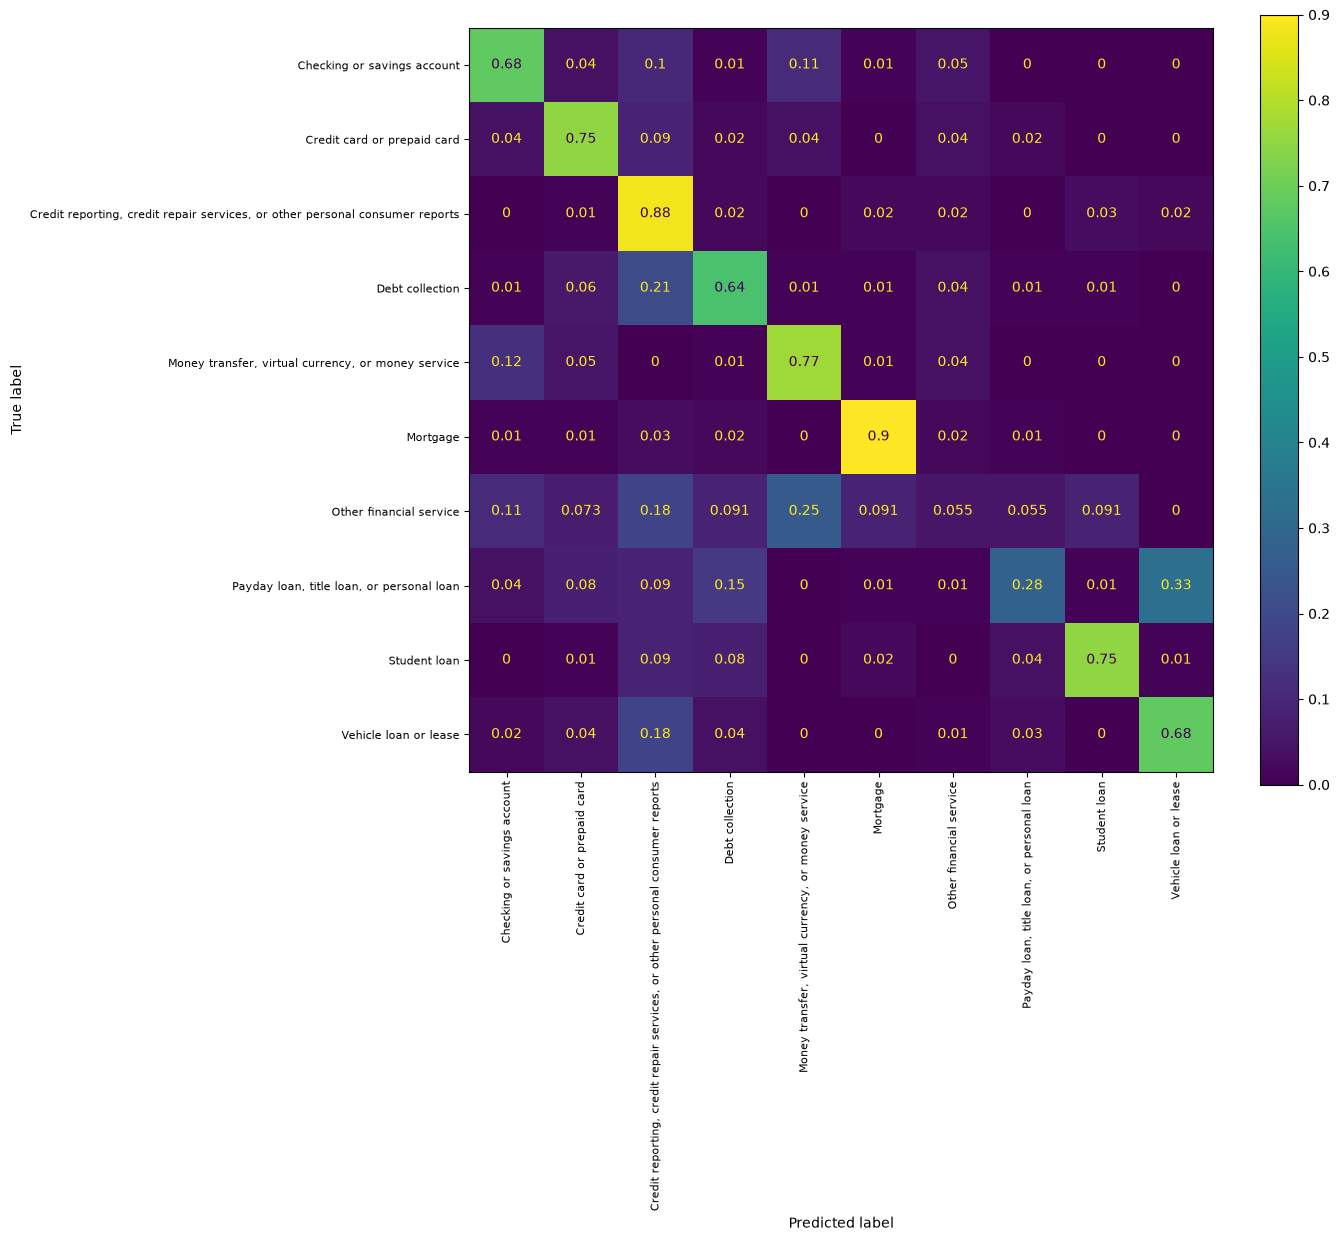

In [132]:
# Matrice de confusion

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    results["Attendue"],
    results["Réponse"],
    xticks_rotation=90,
    normalize="true",
    ax=ax
)

ax.tick_params(axis="both", labelsize=8)

plt.show()

# Analyse des erreurs de classification

In [133]:
# Construire un DataFrame d'analyse des erreurs
errors = results[
    results["Correct"] == False
].copy()

pd.set_option("display.max_colwidth", 100)

errors[
    ["Question", "Attendue", "Réponse"]
].head()

,Question,Attendue,Réponse
0,I received a phone call today telling me a court case was being opened up on me to bring crimina...,Checking or savings account,Debt collection
2,"on XX/XX/16, I received a notification from my bank ( Bank of america ) That there was deposit o...",Checking or savings account,"Credit reporting, credit repair services, or other personal consumer reports"
4,I went to the companys ATM and withdraws some money and the ATM forwarded me {$300.00} that I di...,Checking or savings account,"Money transfer, virtual currency, or money service"
6,Wells Fargo sat in front of my uncle and I and promassed him every thing was taken care of pain ...,Checking or savings account,Mortgage
10,I have a complaint with us bank online money transferring services the problem started on Thursd...,Checking or savings account,"Money transfer, virtual currency, or money service"


In [134]:
print(f"Nombre d'erreurs : {len(errors)}")
print(f"Taux d'erreur : {len(errors) / len(results):.2%}")

Nombre d'erreurs : 319
Taux d'erreur : 33.40%


In [145]:
confusions = (
    errors
    .groupby(["Attendue", "Réponse"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

confusions["% ERR"] = (
    confusions["count"] / len(errors) * 100
)

confusions["% VOL"] = (
    confusions["count"] / len(results) * 100
)

confusions.head(20)

,Attendue,Réponse,count,% ERR,% VOL
52,"Payday loan, title loan, or personal loan",Vehicle loan or lease,33,10.345,3.455
20,Debt collection,"Credit reporting, credit repair services, or other personal consumer reports",21,6.583,2.199
61,Vehicle loan or lease,"Credit reporting, credit repair services, or other personal consumer reports",18,5.643,1.885
48,"Payday loan, title loan, or personal loan",Debt collection,15,4.702,1.571
41,Other financial service,"Money transfer, virtual currency, or money service",14,4.389,1.466
26,"Money transfer, virtual currency, or money service",Checking or savings account,12,3.762,1.257
3,Checking or savings account,"Money transfer, virtual currency, or money service",11,3.448,1.152
39,Other financial service,"Credit reporting, credit repair services, or other personal consumer reports",10,3.135,1.047
1,Checking or savings account,"Credit reporting, credit repair services, or other personal consumer reports",10,3.135,1.047
54,Student loan,"Credit reporting, credit repair services, or other personal consumer reports",9,2.821,0.942


## Analyse du premier couple

In [136]:
# textes associées aux erreurs
errors_texts = errors[
    (errors["Attendue"] == "Payday loan, title loan, or personal loan") &
    (errors["Réponse"] == "Vehicle loan or lease")
]

pd.set_option("display.max_colwidth", 0)
errors_texts["Question"]

659    Auto finance company repossessed vehicle. Vehicle was not damaged before repossession. Vehicle had significant damage after repossession. Auto finance company submitted a claim on my insurance for damage caused by towing company. I have pictures from a few days before the repossession. Towing company also stole cash from Me. Bank filed false insurance claim and I believe that should be illegal.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [137]:
# affiche la/les catégories dans le DF original
for claim in errors_texts["Question"]:
    row = df[df["Consumer Claim"]==claim]
    print(claim[:60], row["Tag"].tolist())

Auto finance company repossessed vehicle. Vehicle was not da ['Consumer Loan']
I originally had a loan set up for a new car I purchased thr ['Consumer Loan']
Monday Capital one called me saying they may repossess may c ['Consumer Loan']
From XXXX XXXX to XXXX XXXX, my husband was XXXX ill in the  ['Consumer Loan']
I sent a query to XXXX XXXX, an online auto loan company. A  ['Consumer Loan']
My car was repossessed XXXX XXXX, 2015 and i had an amount d ['Consumer Loan']
I have had a loan with Ally Bank for my automobile since XX/ ['Consumer Loan']
I paid my auto loan off in full via the lenders website by s ['Consumer Loan']
I applied in 2012, after recently paying my original car loa ['Payday loan, title loan, or personal loan']
I have an auto loan with XXXX XXXX Bank, not by my choice, t ['Consumer Loan']
I have an auto loan with USAA. The funds are electronically  ['Consumer Loan']
i took out a simple interest auto loan at 25 % ish. i have p ['Consumer Loan']
I Purchased a new XXXX X

Prenons plusieurs exemples:

659 => Auto finance company repossessed vehicle. Vehicle was not damaged before repossession. Vehicle had significant damage....
* Réclamation concernant un crédit automobile : le véhicule a été endommagé après sa reprise et une fausse déclaration d’assurance aurait été déposée pour ces dommages.
* Véhicule repris et endommagé après saisie → le texte concerne clairement un crédit automobile, donc « Vehicle loan or lease » semblerait plus précis.

662 => I originally had a loan set up for a new car I purchased through....
* Réclamation concernant un crédit automobile Wells Fargo refinancé et intégralement remboursé, mais pour lequel un prélèvement supplémentaire de 270 $ a été effectué.
* Wells Fargo Dealer Services → crédit pour l’achat d’une voiture, puis refinancement → « Vehicle loan or lease » semble également plus précis.

663 => Monday Capital one called me saying they may repossess may car because I have n't made a payment in a month
* Réclamation contre Capital One concernant la menace de reprise du véhicule après un retard de paiement sur un crédit automobile et des pratiques de recouvrement jugées abusives.
* Capital One / menace de reprise du véhicule → crédit lié à une voiture → « Vehicle loan or lease » semble aussi plus précis.

## Analyse du couple suivant

In [138]:
# textes associées aux erreurs
errors_texts = errors[
    (errors["Attendue"] == "Vehicle loan or lease") &
    (errors["Réponse"] == "Credit reporting, credit repair services, or other personal consumer reports")
]

pd.set_option("display.max_colwidth", 0)
errors_texts["Question"]

855    Summit Financial never helped us recover this account at all. The customer service representatives we're very rude and always lied. I contacted the company through email multiply times to resolve my issues and even when the car was totaled what steps did I need to take next and still no answer. On my credit report they have it as a charge off and that is untrue. Summit Financial needs to fix my records or delete the record and its entirety.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [139]:
# affiche la/les catégories dans le DF original
for claim in errors_texts["Question"]:
    row = df[df["Consumer Claim"]==claim]
    print(claim[:60], row["Tag"].tolist())

Summit Financial never helped us recover this account at all ['Vehicle loan or lease']
I paid this account off through XXXX XXXX and it is still no ['Vehicle loan or lease']
This notice is being sent to you pursuant to a Consent Order ['Vehicle loan or lease']
Was denied a loan to purchase a vehicle in the final stages  ['Vehicle loan or lease']
Dear Consumer Financial, I would like to discuss about paid  ['Vehicle loan or lease']
Beginning in  XXXX  of  2016 , Gateway One Lending began to  ['Vehicle loan or lease']
I contacted Toyota financial services to dispute the points  ['Vehicle loan or lease']
Account was delinquent. I contacted capital and set up payme ['Vehicle loan or lease']
I have reached out to the company to get proof that the repo ['Vehicle loan or lease']
Toyota Financial Services for years did not report this loan ['Vehicle loan or lease']
I was a victim of idenity theft and I sent in all the docume ['Vehicle loan or lease']
XXXX XXXX is reporting on my credit report 

Prenons plusieurs exemples:

855 => Summit Financial never helped us recover this account at all....
* Réclamation concernant un compte Summit Financial incorrectement classé en créance irrécouvrable et l'absence de réponse du service client.
* OUI, Mention explicite de la perte totale du véhicule et d’un compte présenté comme « charge-off »

857 => I paid this account off through XXXX XXXX and it is still no....
* Réclamation concernant un compte payé mais non mis à jour, ce qui bloque l’approbation d’un prêt immobilier.
* Indéterminé, Aucun véhicule, prêt automobile ou crédit-bail n’est mentionné.

869 => This notice is being sent to you pursuant to a Consent Order...
* Avis concernant des informations de crédit potentiellement inexactes communiquées par Universal Acceptance Corporation aux agences de crédit.
* Probablement, Universal Acceptance Corporation est associée au financement automobile et le texte concerne des informations de crédit potentiellement erronées.